# Infinity-Instruct multilingual builder

Builds the multilingual conversation subset from [BAAI/Infinity-Instruct](https://huggingface.co/datasets/BAAI/Infinity-Instruct) and writes `data/infinity_instruct/multi_lingual__infinity_instruct.parquet` for upload to [Pawlo77/mllm-shap](https://huggingface.co/datasets/Pawlo77/mllm-shap) as config **`multi_lingual__infinity_instruct`**.

## Purpose

Selects two-speaker conversations in English, French, and Spanish, applies label/length filters, counts multi-turn explainability tokens (`MAX_TOKEN_COUNT_ML` = 20), augments each surviving prompt into all three languages via translation, and synthesizes per-language Google TTS (`audio__male`, `audio__female`).

This notebook:

1. Loads Infinity-Instruct (`660k`), maps labels to languages, and filters conversations.
2. Builds the multilingual text table (`sentences`, token counts, metadata).
3. Augments with translations (see pipeline sizes below).
4. Synthesizes TTS per language in batches.
5. Saves `multi_lingual__infinity_instruct.parquet` and a JSON text sample.

**Published size (last run):** 435 Hub rows — below `HUB_TARGET_SAMPLES` (1000) because only 145 prompts pass the token budget before translation; each becomes en/fr/es (145 × 3). Caps use `HUB_SAMPLES_PER_LANGUAGE` (= 333) but the filtered pool is smaller.

Run when rebuilding the `multi_lingual__infinity_instruct` Hub config; validate audio and schema with `overview.ipynb` after upload.

## Preprocessing pipeline

Row counts are from the last full notebook run; your numbers may differ slightly if upstream data or filters change.

```mermaid
flowchart TD
  subgraph load["Load"]
    A["BAAI/Infinity-Instruct<br/>config: 660k · train split"]
    B["build_infinity_dataframe"]
    A --> B
  end

  subgraph text["Text filters (en / fr / es)"]
    C["filter_infinity_languages<br/>644,478 rows"]
    D["filter_max_turns · ≤4 turns<br/>637,557"]
    E["Label EDA · drop broken tokens<br/>semantic exclude @ threshold 0.4"]
    F["filter_by_allowed_abilities<br/>313,142"]
    G["dedupe_conversations_semhash<br/>fr ~379 · es ~242 · en ~208k"]
    H["verify_non_english_languages<br/>fr 233 · es 212"]
    I["split_conversation_into_sentences"]
    J["filter_max_sentence_length · ≤200 chars<br/>62,739"]
    B --> C --> D --> E --> F --> G --> H --> I --> J
  end

  subgraph ml["Multilingual export"]
    K["build_multilingual_base<br/>≤666/lang · first human turn<br/>909"]
    L["filter_by_token_count · ≤20 tokens<br/>145"]
    M["sample_n_per_group<br/>cap 333/lang<br/>145"]
    N["augment_with_translations<br/>en / fr / es<br/>435"]
    O["synthesize_multilingual_voices<br/>audio__male · audio__female"]
    P["finalize_multilingual_for_save"]
    Q["save_dataset_and_sample<br/>multi_lingual__infinity_instruct.parquet<br/>435 rows"]
    J --> K --> L --> M --> N --> O --> P --> Q
  end

  subgraph hub["Hub"]
    R["upload_to_hub / Makefile<br/>Pawlo77/mllm-shap"]
    Q --> R
  end
```

# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
from src.setup import configure_notebook_environment

configure_notebook_environment(set_plot_style=True)

In [ ]:
import shutil
from functools import partial
from pprint import pprint
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datasets import DatasetDict
from sentence_transformers import SentenceTransformer

from src import (
    INFINITY_INSTRUCT__CONFIG,
    TTS_CONFIGS,
    augment_with_translations,
    build_infinity_dataframe,
    build_multilingual_base,
    dedupe_conversations_semhash,
    filter_by_allowed_abilities,
    filter_by_token_count,
    filter_infinity_languages,
    filter_max_sentence_length,
    filter_max_turns,
    finalize_multilingual_for_save,
    get_device,
    get_token_model,
    languages_with_min_population,
    message_count_distribution,
    plot_ability_exclusion_curve,
    report_dataset_stats,
    save_dataset_and_sample,
    split_conversation_into_sentences,
    synthesize_multilingual_voices,
    verify_non_english_languages,
)
from src.io import load_dataset as src_load_dataset
from src.languages import (
    LanguageClassifier,
    LanguageTranslator,
)
from src.nlp import TTS
from src.sampling import sample_n_per_group

ENGLISH_LANGUAGE_CODE: str = "en"
FRENCH_LANGUAGE_CODE: str = "fr"
SPANISH_LANGUAGE_CODE: str = "es"
LANGUAGE_MINIMAL_POPULATION: int = 1000
MAXIMUM_NUMBER_OF_TURNS: int = 4
MAX_SENTENCE_LENGTH: int = 200
MAX_TOKEN_COUNT_ML: int = 20
ABILITIES_TO_EXCLUDE: set[str] = {
    "formal logic",
    "logical reasoning",
    "mathematics",
    "programming",
}
LABELS_EXCLUSION_THRESHOLD: float = 0.4

device = get_device()
print(f"Using device: {device}")

model_for_tokens = get_token_model(device)
tts = TTS()
language_classifier = LanguageClassifier()
language_translator = LanguageTranslator()
embedding_model = SentenceTransformer("multi-qa-MiniLM-L6-cos-v1")
load_dataset: Callable[[str], DatasetDict] = partial(
    src_load_dataset, config=INFINITY_INSTRUCT__CONFIG
)

Embedding model is later used to search for labels in dataset that are similar to pre-defined terms. Model has been chosen based on official docs, claimed to be fast and to perform well on small terms - our search is one-word mostly.

# Text dataset preparation and EDA

## Preprocessing

In [ ]:
ds: DatasetDict = load_dataset(INFINITY_INSTRUCT__CONFIG.configs["660k"])
pprint(ds)

In [5]:
pprint(ds["train"].info)

DatasetInfo(description='',
            citation='',
            homepage='',
            license='',
            features={'conversations': [{'from': Value(dtype='string', id=None),
                                         'value': Value(dtype='string',
                                                        id=None)}],
                      'id': Value(dtype='string', id=None),
                      'label': {'ability_en': Sequence(feature=Value(dtype='string',
                                                                     id=None),
                                                       length=-1,
                                                       id=None),
                                'ability_zh': Sequence(feature=Value(dtype='string',
                                                                     id=None),
                                                       length=-1,
                                                       id=None),
                           

In [6]:
pprint(ds["train"][0])

{'conversations': [{'from': 'human',
                    'value': 'In a certain country populated predominantly by '
                             'wizards, there is an impending demonstration '
                             'that needs careful planning to ensure it meets '
                             'specific requirements.\n'
                             '\n'
                             'There is a population of n individuals within '
                             'the city, of which x are wizards committed to '
                             'attending the demonstration. The remaining (n - '
                             'x) individuals, non-wizards, have no intention '
                             'to participate. The city administration will '
                             'acknowledge and act upon the demonstration only '
                             'if it engages at least y percent of the total '
                             'city population. To meet this criterion, wizards '
      

### Dataset preparation

In [7]:
df = build_infinity_dataframe(ds["train"])

In [8]:
languages_with_min_population(df, minimum=LANGUAGE_MINIMAL_POPULATION)

,language,count
0,en,641610
1,zh-cn,7972
2,es,1453
3,fr,1415
4,ko,1308


Out of simple european languages, our further choice is English (en), French (fr) and Spanish (es).

In [9]:
df = filter_infinity_languages(df, INFINITY_INSTRUCT__CONFIG.languages)

Percentage of unique IDs: 100.00%
Max speakers in a conversation: 2
Number of unique sources: 1
Dataframe size after language filtering: 644478.


Each conversation is unique and contains exactly 2 speakers.

In [10]:
df = filter_max_turns(df, MAXIMUM_NUMBER_OF_TURNS)

Remaining samples after filtering long prompts: 637557 (removed 6921)


There are some very long conversations present. We'll not be able to process them efficiently, therefore we drop them here. This does not impact dataset size a lot.

Let's analyze entries labels.

In [11]:
unique_keys: np.ndarray = df["labels"].explode().unique().astype(str)
unique_keys = unique_keys[(unique_keys != "")]
unique_keys.sort()

pprint(unique_keys)

array(['(', ')', '1', ..., 'zoological knowledge', '背景设定', '音声理解'],
      shape=(3662,), dtype='<U137')


In [12]:
labels_lengths: np.ndarray = np.char.str_len(unique_keys)
pprint(unique_keys[labels_lengths == 1])

array(['(', ')', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
      dtype='<U137')


There are some broken labels, we'll filter them out as well.

In [13]:
unique_keys = unique_keys[labels_lengths > 2]
pprint(unique_keys)
del labels_lengths

array(['3d modeling', '3d modeling skills',
       '3d printing technology knowledge', ..., 'zoological knowledge',
       '背景设定', '音声理解'], shape=(3651,), dtype='<U137')


As I operate on small models, I'll exclude math-based problems. Moreover, to minimize number of out-of-box tokens, I remove programming related entries. 

array(['(', ')', '1', ..., 'zoological knowledge', '背景设定', '音声理解'],
      shape=(3662,), dtype='<U137')


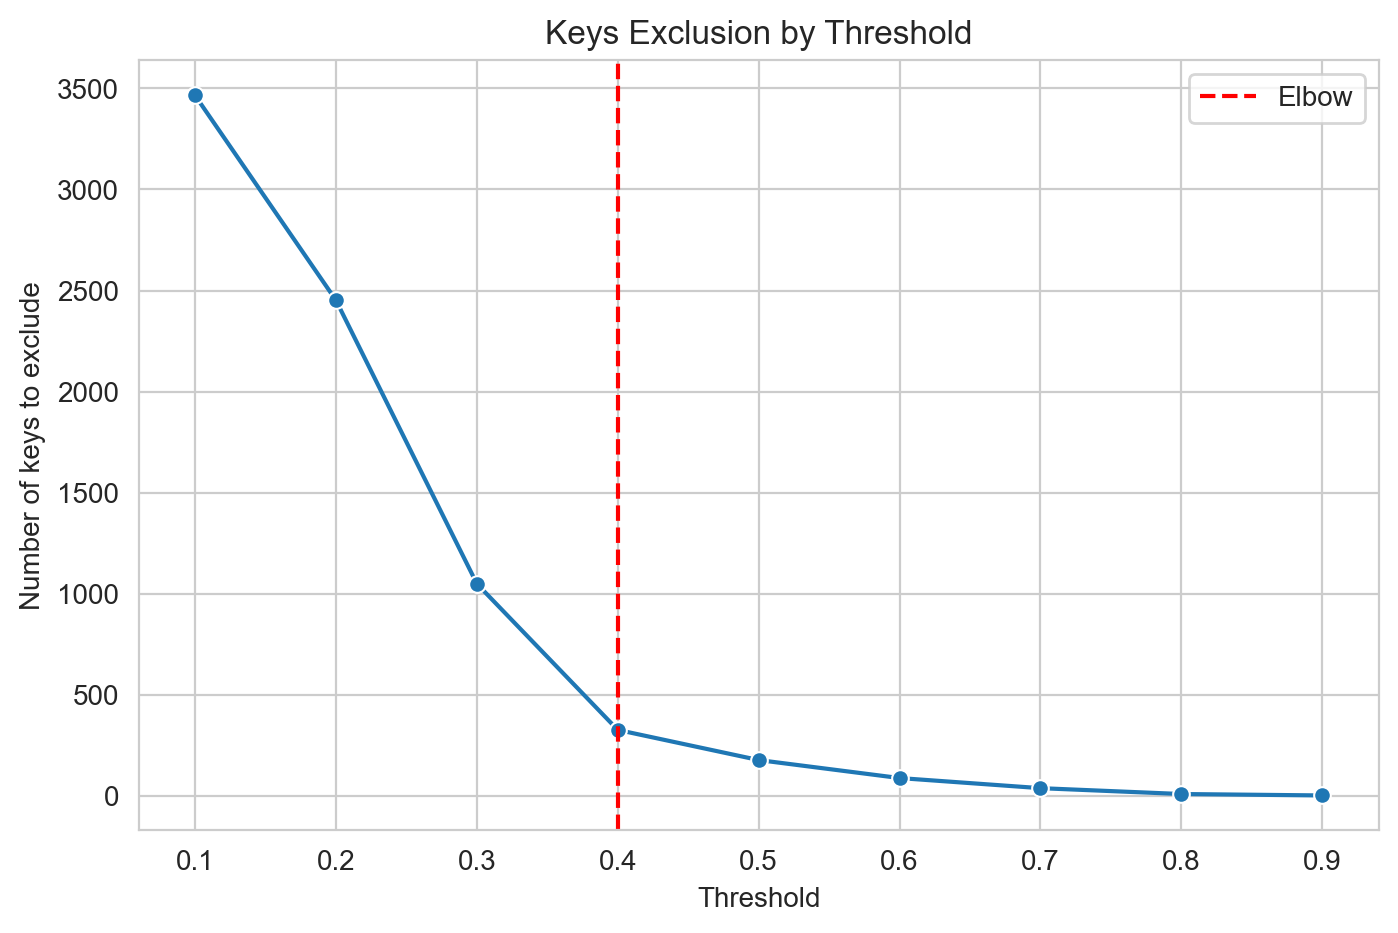

In [14]:
unique_keys = df["labels"].explode().unique().astype(str)
unique_keys = unique_keys[unique_keys != ""]
unique_keys.sort()
pprint(unique_keys)

keys_to_exclude__by_threshold = plot_ability_exclusion_curve(
    unique_keys, ABILITIES_TO_EXCLUDE, embedding_model
)

There is an elbow at 0.4 that we'll use. Below listed labels names that will be excluded indeed are strongly related to attributes I want to exclude.

In [15]:
keys_to_include = (
    set(unique_keys) - keys_to_exclude__by_threshold[LABELS_EXCLUSION_THRESHOLD]
)
df = filter_by_allowed_abilities(df, keys_to_include)

Remaining samples after filtering abilities: 313142 (removed 324415, 50.88%)


In [16]:
pprint(sorted(keys_to_exclude__by_threshold[LABELS_EXCLUSION_THRESHOLD]))
del keys_to_exclude__by_threshold

['ability to explain',
 'ability to solve equations',
 'academic understanding',
 'advanced mathematics',
 'algebra',
 'algebra knowledge',
 'algebra skills',
 'algebraic reasoning',
 'algorithm',
 'algorithm application',
 'algorithm design',
 'algorithm development',
 'analogical reasoning',
 'analysis and reasoning',
 'android programming',
 'application development',
 'application of formulas',
 'arduino programming',
 'argumentation and reasoning',
 'arithmetic',
 'arithmetic calculation',
 'artificial intelligence application',
 'assembly programming',
 'associative reasoning',
 'asynchronous programming',
 'awk programming',
 'bash programming',
 'basic mathematics',
 'brainstorm',
 'c programming',
 'c# programming',
 'c++ programming',
 'calculus',
 'calculus ability',
 'calculus knowledge',
 'categorical reasoning',
 'causal reasoning',
 'clinical reasoning',
 'clojure programming',
 'code completed',
 'code conversion',
 'code design',
 'code development',
 'code editing',
 

Following cell performs deduplication based on conversation prompt messages using semhash with its default configuration.

In [ ]:
df = dedupe_conversations_semhash(df)

After deduplication on prompt text, non-English languages are sparse vs English (last run: fr ~379, es ~242; en ~208k). Later cells build the multilingual export from this filtered table.

In [18]:
df["language"].value_counts()

language
en    207889
fr       379
es       242
Name: count, dtype: int64

In [19]:
df[df["language"] == FRENCH_LANGUAGE_CODE].head(10).reset_index(drop=True)

,conversation,labels,language,n_messages,conversation__joined
0,"[{'from': 'human', 'value': 'Nommez NAME_1 les...","[multicultural understanding, data analysis, i...",fr,2,Nommez NAME_1 les meilleurs joueurs de footbal...
1,"[{'from': 'human', 'value': 'pouvez-vous nomme...","[multicultural understanding, search knowledge...",fr,2,pouvez-vous nommer la capitale du pays NAME_1 ...
2,"[{'from': 'human', 'value': 'Can you design a ...","[graphic design, creative design, problem solved]",fr,2,Can you design a unique logo from scratch? Whi...
3,"[{'from': 'human', 'value': 'Comment traduire ...","[translation, oral communication]",fr,2,"Comment traduire ""We Have No Moat"" en français..."
4,"[{'from': 'human', 'value': 'Question : Rédige...","[text generation, search knowledge, text editi...",fr,2,Question : Rédigez en français un article info...
5,"[{'from': 'human', 'value': '### Human: Your t...","[text classification, categorization and tags]",fr,2,### Human: Your task is to classify texts.\n\n...
6,"[{'from': 'human', 'value': 'Traduzca el sigui...","[project management, legal knowledge, translat...",fr,2,"Traduzca el siguiente documento al francés: ""L..."
7,"[{'from': 'human', 'value': 'Pourriez-vous réd...","[multicultural understanding, text generation,...",fr,2,Pourriez-vous rédiger en français une descript...
8,"[{'from': 'human', 'value': 'Réécris moi ça en...",[text-to-speech],fr,4,Réécris moi ça en ajoutant des trucs pour la p...
9,"[{'from': 'human', 'value': 'Bonjour, avez-vou...","[multicultural understanding, dialogue managem...",fr,2,"Bonjour, avez-vous la capacité de converser en..."


There are some problems with non-english languages labels (row 2), we'll filter them out.

In [20]:
df = verify_non_english_languages(
    df, language_classifier, english_code=ENGLISH_LANGUAGE_CODE
)

  0%|          | 0/621 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Number of incorrect language detections: 176 (28.34%)


Around 30% of non-english entries were incorrectly classified, for safety we'll remove them.

After label cleanup and language verification, non-English rows stay in the low hundreds per language (last run: fr 233, es 212).

In [21]:
df["language"].value_counts()

language
en    207889
fr       233
es       212
Name: count, dtype: int64

Next step is to split prompt's messages into separate sentences.

In [22]:
df = split_conversation_into_sentences(df)
df.head(3)

,conversation,labels,language,n_messages,conversation__joined,sentences__num
0,"[{'from': 'human', 'value': ['Compose a 1500-w...","[literature search skills, writing skills, inf...",en,2,Compose a 1500-word analytical essay formatted...,121
1,"[{'from': 'human', 'value': ['Analyze the two ...","[problem solved, data analysis]",en,2,Analyze the two tables presented below concern...,11
2,"[{'from': 'human', 'value': ['Create a vividly...",[content filtering],en,2,Create a vividly detailed and provocative MCU ...,4


In [23]:
df = filter_max_sentence_length(df, MAX_SENTENCE_LENGTH)

Remaining samples after max sentence length filter: 62739 (removed 145595, 69.89%)


Let's check for number of turns distribution - one-turn conversations clearly dominate. For clear display we exclude irrelevant entries with less than 50 records.

In [24]:
message_count_distribution(df, minimum=50)

,n_messages,count
0,2,61148
1,6,613
2,4,559
3,8,419


# Multilingual dataset

From the filtered table, `build_multilingual_base` samples up to `2 × HUB_SAMPLES_PER_LANGUAGE` rows per language (666 with default constants), keeps the first human turn only (one-turn conversations), then applies the token and sampling steps below.

Last run row counts:

| Step | Rows |
|------|------|
| After `build_multilingual_base` | 909 |
| After `token_count ≤ 20` | 145 |
| After `sample_n_per_group` (cap 333/lang) | 145 |
| After `augment_with_translations` | 435 (145 × en/fr/es) |
| Saved parquet | **435** |

`finalize_multilingual_for_save` aligns the schema with VoiceBench single-turn exports (`sentences` + audio columns; no `conversation` column in the parquet).

### Dataset preparation

In [25]:
from src.constants import HUB_SAMPLES_PER_LANGUAGE

multilingual__df = build_multilingual_base(
    df, per_language_n=HUB_SAMPLES_PER_LANGUAGE * 2
)

Number of unique text entries and size of the multilingual dataset: 909


In [26]:
multilingual__df = filter_by_token_count(
    multilingual__df, model_for_tokens, max_token_count=MAX_TOKEN_COUNT_ML
)

multi-turn token counting:   0%|          | 0/909 [00:00<?, ?it/s]

Computed token counts for 909 entries.
Candidates with token_count <= 20: 145


Text(0.5, 0, 'token_count')

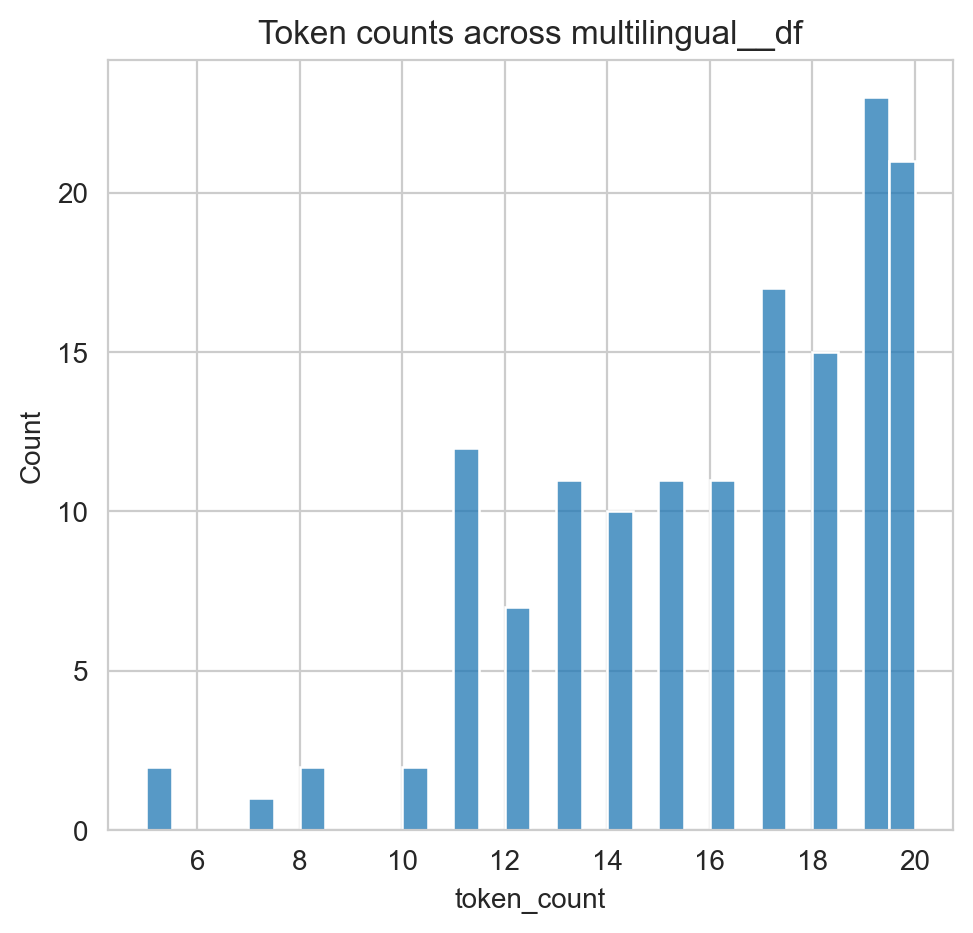

In [27]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(multilingual__df["token_count"], bins=30, kde=False)
plt.title("Token counts across multilingual__df")
plt.xlabel("token_count")

In [28]:
multilingual__df = sample_n_per_group(
    multilingual__df, "language", HUB_SAMPLES_PER_LANGUAGE
)

In [29]:
multilingual__df.describe()

,n_messages,sentences__num,token_count
count,145.000000,145.000000,145.000000
mean,1.206897,1.172414,15.924138
std,0.992308,0.430517,3.440128
min,1.000000,1.000000,5.000000
25%,1.000000,1.000000,13.000000
50%,1.000000,1.000000,17.000000
75%,1.000000,1.000000,19.000000
max,7.000000,4.000000,20.000000


Text(0.5, 0, 'token_count')

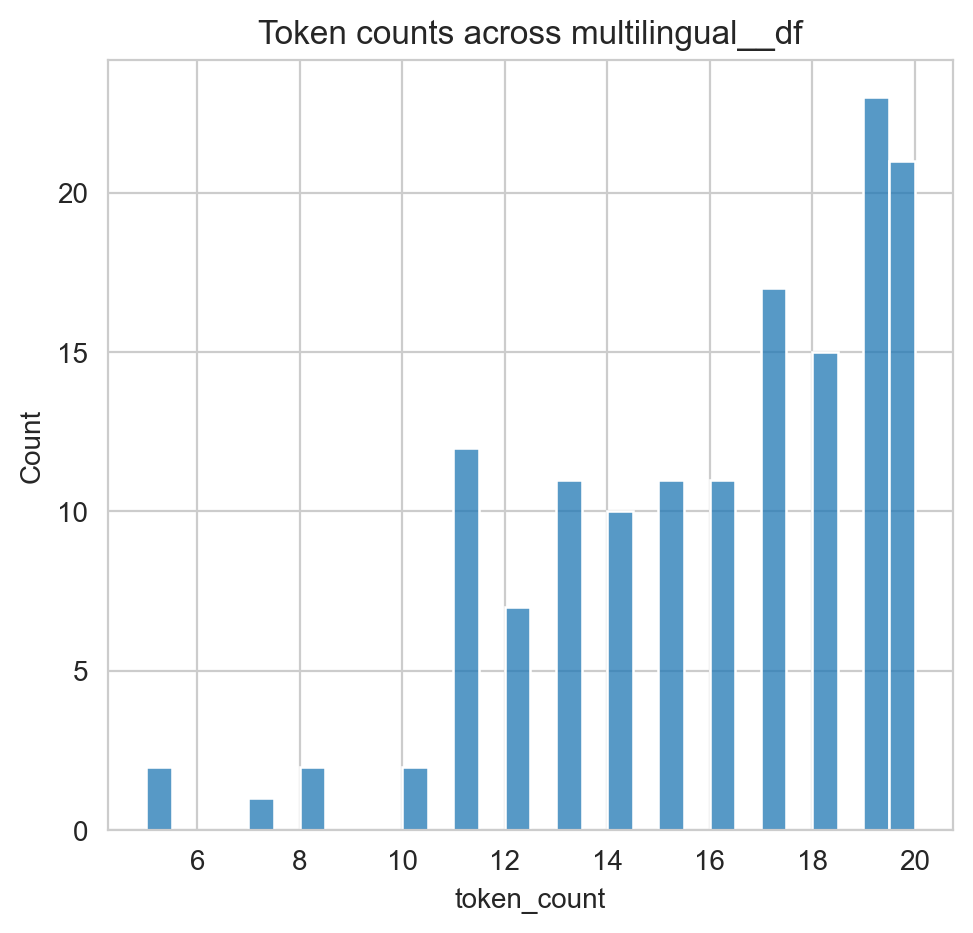

In [30]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(multilingual__df["token_count"], bins=30, kde=False)
plt.title("Token counts across multilingual__df")
plt.xlabel("token_count")

Lets check for most popular labels:

In [31]:
counts: np.ndarray = multilingual__df["labels"].explode().value_counts()
pprint(counts)
del counts

labels
answer to the question         28
information search             27
multicultural understanding    26
problem solved                 19
translation                    18
                               ..
concept design                  1
fantasy literature              1
ancient mythology knowledge     1
narrative creation              1
dialogue comprehension          1
Name: count, Length: 153, dtype: int64


In [32]:
multilingual__df = await augment_with_translations(
    multilingual__df, language_translator, INFINITY_INSTRUCT__CONFIG.languages
)

Translating from es...


100%|██████████| 24/24 [00:02<00:00, 10.31it/s]


Translating from en...


100%|██████████| 99/99 [00:02<00:00, 46.74it/s]


Translating from fr...


100%|██████████| 22/22 [00:01<00:00, 17.57it/s]


In [33]:
multilingual__df[
    multilingual__df["language"] != multilingual__df["original_language"]
].head(3)

,prompt,labels,language,n_messages,conversation__joined,sentences__num,sentences,original_language,token_count
145,"[{'from': 'human', 'value': ['Por favor, tradu...","[multicultural understanding, translation]",en,1,Please translate the following sentence into F...,1,[Please translate the following sentence into ...,es,16
146,"[{'from': 'human', 'value': ['Lee el 'encargo'...","[multicultural understanding, translation]",en,1,Read the 'order' and translate it into French....,2,[Read the 'order' and translate it into French...,es,20
147,"[{'from': 'human', 'value': ['Cuéntame sobre e...","[answer to the question, natural language unde...",en,1,Tell me about the most surprising recent NAME_...,1,[Tell me about the most surprising recent NAME...,es,20


In [34]:
multilingual__df["language"].value_counts()

language
en    145
es    145
fr    145
Name: count, dtype: int64

Lets synthesize audio representation.

In [ ]:
multilingual__df = await synthesize_multilingual_voices(
    multilingual__df, tts, TTS_CONFIGS
)

### Stats

In [37]:
report_dataset_stats(multilingual__df, text_col="conversation__joined")

{'audio__female__duration__average': 5.32,
 'audio__female__duration__total': 2316.14,
 'audio__male__duration__average': 5.17,
 'audio__male__duration__total': 2250.62,
 'avg_characters__num': 86.29,
 'avg_sentences__num': 1.17,
 'characters__num': 37534,
 'min_sentences__num': 1,
 'rows__num': 435,
 'total_sentences__num': 510,
 'unique_entries__num': 434,
 'unique_entries__pct': 99.77}
{'2n^2': 230730,
 '3n^2': 345942,
 '4n^2': 461064,
 'frac 0.1': 12489120.0,
 'frac 0.2': 24978240.0,
 'n^2': 115419}


,datasets,num_rows,total_characters,avg_num_characters,avg_num_sentences,total_sentences
0,unknown,435,37534,86.285057,1.172414,510


## Save dataset and samples

In [38]:
multilingual__df__to_save = finalize_multilingual_for_save(multilingual__df)
save_dataset_and_sample(
    multilingual__df__to_save,
    INFINITY_INSTRUCT__CONFIG.data_dir,
    "multi_lingual__infinity_instruct",
    group_col="labels",
    text_col="sentences",
).head(3)

Saved 435 rows to multi_lingual__infinity_instruct.parquet


,labels,sentences
0,ability to plan,[What are the steps and considerations involve...
1,ability to summarize,[Could you succinctly describe GPT in 7 specia...
2,analysis and comparison,[How do you compare to other open source large...


In [39]:
multilingual__df__to_save.head(3)

,labels,language,n_messages,sentences__num,sentences,original_language,token_count,audio__male,audio__female,audio__male__duration,audio__female__duration
0,"[common sense q&a, time conversion]",en,1,1,[Provide the standard time format for 2315 hou...,en,11,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[4.872],[5.112]
1,"[emotional simulation, communication skills, n...",en,1,1,"[You are LAN_WJ, an android designed to emulat...",en,16,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[6.336],[6.72]
2,"[english grammar check, natural language under...",en,1,2,"[Is the sentence ""They enjoys reading"" constru...",en,18,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,[b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x0...,"[4.56, 1.992]","[5.016, 2.088]"



### Processed samples

### Section cleanup

In [40]:
del multilingual__df

# Cleanup

In [41]:
shutil.rmtree(INFINITY_INSTRUCT__CONFIG.cache_dir)